**Programming Assignment 2 CNN and data competition**

**Import tenserflow**

In [3]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

SEED = 123
tf.random.set_seed(SEED)
np.random.seed(SEED)

print("TF version:", tf.__version__)

TF version: 2.20.0


**Load and Visualize the sample (cifar 10)**

Train: (50000, 32, 32, 3) (50000, 1)
Test : (10000, 32, 32, 3) (10000, 1)
Train class distribution: [5000 5000 5000 5000 5000 5000 5000 5000 5000 5000]
Test class distribution : [1000 1000 1000 1000 1000 1000 1000 1000 1000 1000]


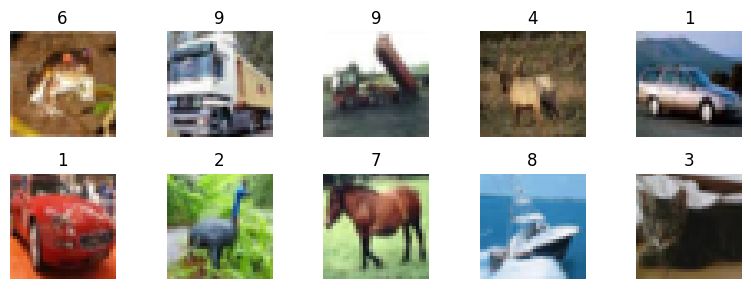

In [16]:
AUTOTUNE = tf.data.AUTOTUNE

IMG_SIZE = (32, 32)
BATCH_SIZE = 128

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
x_tr, x_val, y_tr, y_val = train_test_split(
    x_train, y_train, test_size=0.1, random_state=42, stratify=y_train
)

print("Train:", x_train.shape, y_train.shape)
print("Test :", x_test.shape, y_test.shape)

y_train_flat = y_train.flatten()
y_test_flat = y_test.flatten()

train_counts = np.bincount(y_train_flat)
test_counts = np.bincount(y_test_flat)

print("Train class distribution:", train_counts)
print("Test class distribution :", test_counts)

plt.figure(figsize=(8, 3))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_train[i])  # no grayscale
    plt.title(int(y_train[i][0]))
    plt.axis("off")
plt.tight_layout()
plt.show()

**Construct a CNN to predict the image labels (cifar 10)**

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_aug (Sequential)           │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ norm (Sequential)               │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_46 (Conv2D)              │ (None, 32, 32, 32)     │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_46          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_46 (Activation)      │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_47 (Conv2D)              │ (None, 32, 32, 32)     │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_47          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_47 (Activation)      │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_28 (Dropout)            │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_48 (Conv2D)              │ (None, 16, 16, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_48          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_48 (Activation)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_49 (Conv2D)              │ (None, 16, 16, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_49          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_49 (Activation)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_24 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_29 (Dropout)            │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_50 (Conv2D)              │ (None, 8, 8, 128)      │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_50          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_50 (Activation)      │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_51 (Conv2D)              │ (None, 8, 8, 128)      │       147,456 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 4,852,074 (18.51 MB)

 Trainable params: 4,848,106 (18.49 MB)

 Non-trainable params: 3,968 (15.50 KB)

Epoch 1/200
352/352 ━━━━━━━━━━━━━━━━━━━━ 186s 515ms/step - accuracy: 0.1891 - loss: 3.1784 - val_accuracy: 0.3818 - val_loss: 2.2127 - learning_rate: 0.0010
Epoch 2/200
352/352 ━━━━━━━━━━━━━━━━━━━━ 182s 516ms/step - accuracy: 0.4002 - loss: 2.1452 - val_accuracy: 0.4386 - val_loss: 1.9031 - learning_rate: 0.0010
Epoch 3/200
352/352 ━━━━━━━━━━━━━━━━━━━━ 188s 535ms/step - accuracy: 0.5187 - loss: 1.7414 - val_accuracy: 0.5234 - val_loss: 1.7539 - learning_rate: 0.0010
Epoch 4/200
352/352 ━━━━━━━━━━━━━━━━━━━━ 199s 565ms/step - accuracy: 0.5772 - loss: 1.5527 - val_accuracy: 0.4972 - val_loss: 2.0481 - learning_rate: 0.0010
Epoch 5/200
352/352 ━━━━━━━━━━━━━━━━━━━━ 198s 563ms/step - accuracy: 0.6142 - loss: 1.4443 - val_accuracy: 0.5912 - val_loss: 1.5139 - learning_rate: 0.0010
Epoch 6/200
352/352 ━━━━━━━━━━━━━━━━━━━━ 202s 575ms/step - accuracy: 0.6350 - loss: 1.3767 - val_accuracy: 0.6372 - val_loss: 1.3649 - learning_rate: 0.0010
Epoch 7/200
352/352 ━━━━━━━━━━━━━━━━━━━━ 202s 573ms/step -

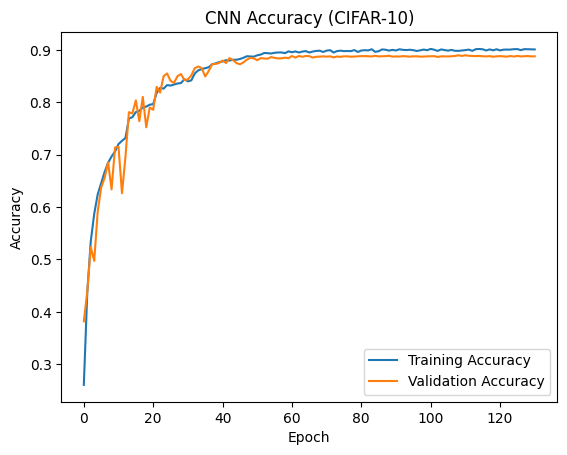

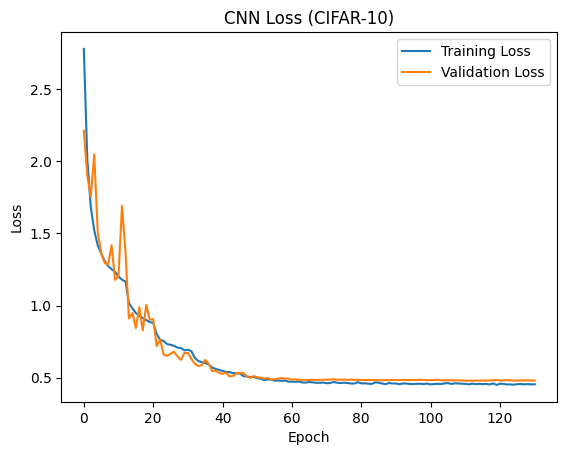

Final Test Accuracy: 0.8803 | Test Loss: 0.5302


In [17]:
#data augmentation
data_aug = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomTranslation(0.1, 0.1),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
], name="data_aug")

y_tr = y_tr.flatten()
y_val = y_val.flatten()
y_test = y_test.flatten()

mean = np.mean(x_tr, axis=(0, 1, 2), keepdims=True) / 255.0
std  = np.std(x_tr, axis=(0, 1, 2), keepdims=True) / 255.0

normalizer = tf.keras.Sequential([
    layers.Rescaling(1./255),
    layers.Normalization(mean=mean, variance=std**2),
], name="norm")

lr_cb = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss", factor=0.5, patience=3, verbose=1, min_lr=1e-6
)

early_cb = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=20, restore_best_weights=True, verbose=1
)

train_ds = tf.data.Dataset.from_tensor_slices((x_tr, y_tr)) \
    .shuffle(50000) \
    .batch(BATCH_SIZE) \
    .prefetch(AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((x_val, y_val)) \
    .batch(BATCH_SIZE) \
    .prefetch(AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((x_test, y_test.flatten())) \
    .batch(BATCH_SIZE) \
    .prefetch(AUTOTUNE)

model = models.Sequential([
    layers.Input(shape=IMG_SIZE + (3,)),
    data_aug,
    normalizer,

    layers.Conv2D(32, 3, padding="same", use_bias=False, kernel_regularizer=regularizers.l2(5e-4)),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.Conv2D(32, 3, padding="same", use_bias=False, kernel_regularizer=regularizers.l2(5e-4)),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D(),
    layers.Dropout(0.1),

    layers.Conv2D(64, 3, padding="same", use_bias=False, kernel_regularizer=regularizers.l2(5e-4)),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.Conv2D(64, 3, padding="same", use_bias=False, kernel_regularizer=regularizers.l2(5e-4)),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D(),
    layers.Dropout(0.15),

    layers.Conv2D(128, 3, padding="same", use_bias=False, kernel_regularizer=regularizers.l2(5e-4)),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.Conv2D(128, 3, padding="same", use_bias=False, kernel_regularizer=regularizers.l2(5e-4)),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D(),
    layers.Dropout(0.2),

    layers.Conv2D(256, 3, padding="same", use_bias=False, kernel_regularizer=regularizers.l2(5e-4)),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.Conv2D(256, 3, padding="same", use_bias=False, kernel_regularizer=regularizers.l2(5e-4)),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    layers.Conv2D(512, 3, padding="same", use_bias=False, kernel_regularizer=regularizers.l2(5e-4)),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.Conv2D(512, 3, padding="same", use_bias=False, kernel_regularizer=regularizers.l2(5e-4)),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D(),
    layers.Dropout(0.3),

    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation="relu", kernel_regularizer=regularizers.l2(5e-4)),
    layers.Dropout(0.4),
    layers.Dense(10, activation="softmax")
])

model.summary()

steps_per_epoch = int(np.ceil(len(x_tr) / BATCH_SIZE))
lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=2e-3,
    decay_steps=steps_per_epoch * 150,
    alpha=1e-2
)

opt = tf.keras.optimizers.Adam(learning_rate=1e-3)

loss_fn = tf.keras.losses.SparseCategoricalCrossentropy()

model.compile(
    optimizer=opt,
    loss=loss_fn,
    metrics=["accuracy"]
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=200,
    callbacks=[early_cb, lr_cb],
    verbose=1
)

plt.figure()
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("CNN Accuracy (CIFAR-10)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure()
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("CNN Loss (CIFAR-10)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Final Test Accuracy: {test_acc:.4f} | Test Loss: {test_loss:.4f}")

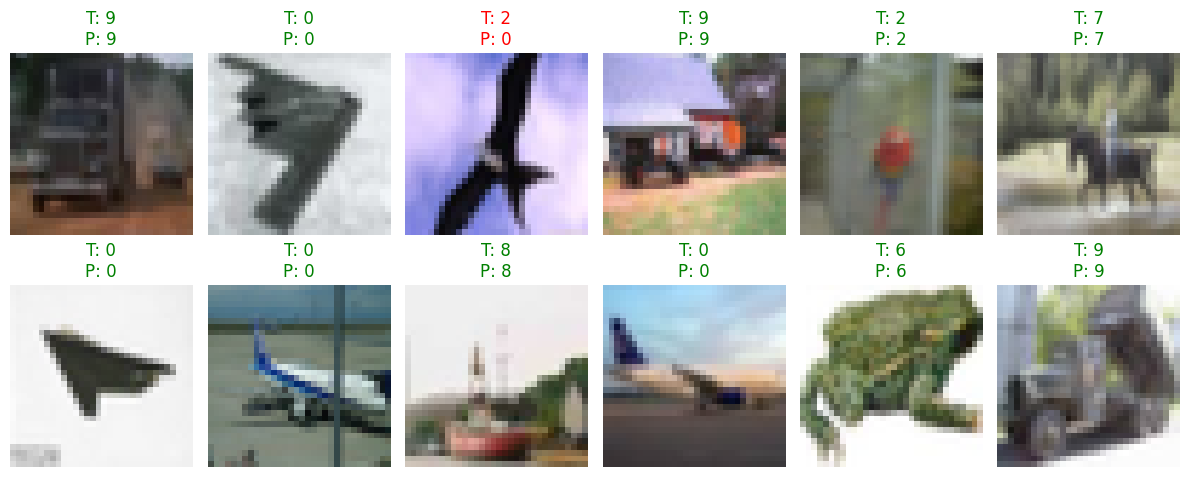

In [11]:
from PredictionViewer import PredictionViewer

viewer = PredictionViewer(model)
viewer.show_predictions(x_test, y_test.flatten(), num_images=12)